In [1]:

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:         
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f" {len(gpus)} GPU(s) ready:")
    for g in gpus:
        print(f"   {g.name}")
else:
    raise SystemExit(" Enable GPU in Session Options!")


2026-04-13 17:08:57.364850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776100137.874190      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776100137.991527      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776100139.082283      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776100139.082322      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776100139.082324      23 computation_placer.cc:177] computation placer alr

 2 GPU(s) ready:
   /physical_device:GPU:0
   /physical_device:GPU:1


In [2]:

!pip install -q split-folders

import os, shutil, random, math, cv2
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import splitfolders

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(" All imports done")


 All imports done


In [3]:

INPUT_SIZE    = 128
BATCH_SIZE    = 32
LEARNING_RATE = 0.0001
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 30

POOL_REAL  = '/kaggle/working/pool/real'
POOL_FAKE  = '/kaggle/working/pool/fake'
SPLIT_OUT  = '/kaggle/working/split'
BEST_MODEL = '/kaggle/working/best_model.h5'

for d in [POOL_REAL, POOL_FAKE]:
    os.makedirs(d, exist_ok=True)

DS_BASE = '/kaggle/input/datasets'

_140k_inner = 'real vs fake'
if not os.path.exists(f'{DS_BASE}/xhlulu/140k-real-and-fake-faces/real_vs_fake/real vs fake'):
    _140k_inner = 'real-vs-fake'    
BASE_140K   = f'{DS_BASE}/xhlulu/140k-real-and-fake-faces/real_vs_fake/{_140k_inner}'

BASE_MANJIL = f'{DS_BASE}/manjilkarki/deepfake-and-real-images/Dataset'

BASE_CELEB  = f'{DS_BASE}/reubensuju/celeb-df-v2'


BASE_CIPLAB = f'{DS_BASE}/ciplab/real-and-fake-face-detection/real_and_fake_face'

BASE_HARD   = f'{DS_BASE}/hamzaboulahia/hardfakevsrealfaces'

print(" Path Verification:")
checks = {
    '140k/train/real'   : f'{BASE_140K}/train/real',
    '140k/train/fake'   : f'{BASE_140K}/train/fake',
    'manjil/Train/Real' : f'{BASE_MANJIL}/Train/Real',
    'manjil/Train/Fake' : f'{BASE_MANJIL}/Train/Fake',
    'ciplab/real'       : f'{BASE_CIPLAB}/training_real',
    'ciplab/fake'       : f'{BASE_CIPLAB}/training_fake',
    'hardfake/real'     : f'{BASE_HARD}/real',
    'hardfake/fake'     : f'{BASE_HARD}/fake',
    'celeb/real videos' : f'{BASE_CELEB}/Celeb-real',
    'celeb/fake videos' : f'{BASE_CELEB}/Celeb-synthesis',
}
for name, path in checks.items():
    exists = os.path.exists(path)
    count  = len(os.listdir(path)) if exists else 0
    print(f"  {'' if exists else ''} {name}: {count:,}  →  ...{path[30:]}")


 Path Verification:
   140k/train/real: 50,000  →  ...140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real
   140k/train/fake: 50,000  →  ...140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/fake
   manjil/Train/Real: 70,001  →  ...arki/deepfake-and-real-images/Dataset/Train/Real
   manjil/Train/Fake: 70,001  →  ...arki/deepfake-and-real-images/Dataset/Train/Fake
   ciplab/real: 1,081  →  ...real-and-fake-face-detection/real_and_fake_face/training_real
   ciplab/fake: 960  →  ...real-and-fake-face-detection/real_and_fake_face/training_fake
   hardfake/real: 589  →  ...ulahia/hardfakevsrealfaces/real
   hardfake/fake: 700  →  ...ulahia/hardfakevsrealfaces/fake
   celeb/real videos: 590  →  ...uju/celeb-df-v2/Celeb-real
   celeb/fake videos: 5,639  →  ...uju/celeb-df-v2/Celeb-synthesis


In [4]:
def collect_images(src_dir, dst_dir, tag, limit=None):
    if not src_dir or not os.path.exists(src_dir):
        print(f"    Skipped (not found): {src_dir}")
        return 0
    files = [f for f in os.listdir(src_dir)
             if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not files:
        print(f"   No images in: {src_dir}")
        return 0
    random.shuffle(files)
    if limit: files = files[:limit]
    for i, fname in enumerate(files):
        ext = os.path.splitext(fname)[1].lower() or '.jpg'
        shutil.copy2(os.path.join(src_dir, fname),
                     os.path.join(dst_dir, f"{tag}_{i:07d}{ext}"))
    print(f"   +{len(files):,}  ←  .../{os.path.basename(src_dir)}/")
    return len(files)

print(" Helper ready")


 Helper ready


In [5]:

print(" Dataset 1: 140k Real and Fake Faces")
n_r = n_f = 0
for split in ['train', 'valid', 'test']:
    n_r += collect_images(f'{BASE_140K}/{split}/real', POOL_REAL, f'140k_{split}_r')
    n_f += collect_images(f'{BASE_140K}/{split}/fake', POOL_FAKE, f'140k_{split}_f')
print(f"  → {n_r:,} real | {n_f:,} fake\n")


 Dataset 1: 140k Real and Fake Faces
   +50,000  ←  .../real/
   +50,000  ←  .../fake/
   +10,000  ←  .../real/
   +10,000  ←  .../fake/
   +10,000  ←  .../real/
   +10,000  ←  .../fake/
  → 70,000 real | 70,000 fake



In [6]:
print(" Dataset 2: Deepfake and Real Images (Manjil)")
n_r = n_f = 0
for split in ['Train', 'Validation', 'Test']:
    n_r += collect_images(f'{BASE_MANJIL}/{split}/Real', POOL_REAL, f'mjl_{split}_r')
    n_f += collect_images(f'{BASE_MANJIL}/{split}/Fake', POOL_FAKE, f'mjl_{split}_f')
print(f"  → {n_r:,} real | {n_f:,} fake\n")


 Dataset 2: Deepfake and Real Images (Manjil)
   +70,001  ←  .../Real/
   +70,001  ←  .../Fake/
   +19,787  ←  .../Real/
   +19,641  ←  .../Fake/
   +5,413  ←  .../Real/
   +5,492  ←  .../Fake/
  → 95,201 real | 95,134 fake



In [7]:

SKIP_CELEB = False  

if SKIP_CELEB:
    print("  Celeb-DF skipped")
else:
    def extract_frames(video_dir, out_dir, tag, max_videos=80):
        os.makedirs(out_dir, exist_ok=True)
        videos = [f for f in os.listdir(video_dir) if f.endswith('.mp4')][:max_videos]
        total = 0
        for vid in videos:
            cap = cv2.VideoCapture(os.path.join(video_dir, vid))
            fps = max(1, math.floor(cap.get(cv2.CAP_PROP_FPS)))
            vname = os.path.splitext(vid)[0]
            fid = 0
            while cap.isOpened():
                curr = cap.get(cv2.CAP_PROP_POS_FRAMES)
                ret, frame = cap.read()
                if not ret: break
                if int(curr) % fps == 0:
                    cv2.imwrite(os.path.join(out_dir, f"{tag}_{vname}_{fid:04d}.jpg"), frame)
                    fid += 1; total += 1
            cap.release()
        return total

    print(" Dataset 3: Celeb-DF v2 (extracting frames from videos...)")
    nr = extract_frames(f'{BASE_CELEB}/Celeb-real',      POOL_REAL, 'cel_r', max_videos=80)
    nf = extract_frames(f'{BASE_CELEB}/Celeb-synthesis', POOL_FAKE, 'cel_f', max_videos=80)
    print(f"  → {nr:,} real frames | {nf:,} fake frames\n")


 Dataset 3: Celeb-DF v2 (extracting frames from videos...)
  → 1,132 real frames | 1,101 fake frames



In [8]:

print(" Dataset 4: Real and Fake Face Detection (CIPLAB)")
n_r = collect_images(f'{BASE_CIPLAB}/training_real', POOL_REAL, 'cip_r')
n_f = collect_images(f'{BASE_CIPLAB}/training_fake', POOL_FAKE, 'cip_f')
print(f"  → {n_r:,} real | {n_f:,} fake\n")


 Dataset 4: Real and Fake Face Detection (CIPLAB)
   +1,081  ←  .../training_real/
   +960  ←  .../training_fake/
  → 1,081 real | 960 fake



In [9]:

print(" Dataset 5: Fake-Vs-Real Faces Hard")
n_r = collect_images(f'{BASE_HARD}/real', POOL_REAL, 'hard_r')
n_f = collect_images(f'{BASE_HARD}/fake', POOL_FAKE, 'hard_f')
print(f"  → {n_r:,} real | {n_f:,} fake\n")


 Dataset 5: Fake-Vs-Real Faces Hard
   +589  ←  .../real/
   +700  ←  .../fake/
  → 589 real | 700 fake



In [10]:

tr = len(os.listdir(POOL_REAL))
tf = len(os.listdir(POOL_FAKE))
print("="*50)
print(f" TOTAL POOL: {tr:,} real + {tf:,} fake = {tr+tf:,} images")
print("="*50)


 TOTAL POOL: 168,003 real + 167,895 fake = 335,898 images


In [11]:

random.seed(1337)
real_files = os.listdir(POOL_REAL)
fake_files = os.listdir(POOL_FAKE)

min_count  = min(len(real_files), len(fake_files))
real_files = random.sample(real_files, min_count)
fake_files = random.sample(fake_files, min_count)
print(f"Balanced: {min_count:,} real + {min_count:,} fake = {min_count*2:,} total")

BAL = '/kaggle/working/balanced'
os.makedirs(f'{BAL}/real', exist_ok=True)
os.makedirs(f'{BAL}/fake', exist_ok=True)

for f in real_files: shutil.copy2(os.path.join(POOL_REAL,f), f'{BAL}/real/{f}')
for f in fake_files: shutil.copy2(os.path.join(POOL_FAKE,f), f'{BAL}/fake/{f}')

splitfolders.ratio(BAL, output=SPLIT_OUT, seed=1337, ratio=(0.8, 0.1, 0.1))

for split in ['train','val','test']:
    for cls in ['real','fake']:
        n = len(os.listdir(f'{SPLIT_OUT}/{split}/{cls}'))
        print(f"  {split}/{cls}: {n:,}")


Balanced: 167,895 real + 167,895 fake = 335,790 total


Copying files: 335790 files [01:30, 3698.98 files/s]

  train/real: 134,316
  train/fake: 134,316
  val/real: 16,789
  val/fake: 16,789
  test/real: 16,790
  test/fake: 16,790


In [12]:

train_datagen = ImageDataGenerator(
  
    rotation_range   = 10,
    width_shift_range= 0.1,
    height_shift_range=0.1,
    shear_range      = 0.2,
    zoom_range       = 0.1,
    horizontal_flip  = True,
    fill_mode        = 'nearest'
)
eval_datagen = ImageDataGenerator()   

train_gen = train_datagen.flow_from_directory(
    f'{SPLIT_OUT}/train', target_size=(INPUT_SIZE,INPUT_SIZE),
    color_mode='rgb', class_mode='binary', batch_size=BATCH_SIZE, shuffle=True)
val_gen = eval_datagen.flow_from_directory(
    f'{SPLIT_OUT}/val', target_size=(INPUT_SIZE,INPUT_SIZE),
    color_mode='rgb', class_mode='binary', batch_size=BATCH_SIZE, shuffle=False)
test_gen = eval_datagen.flow_from_directory(
    f'{SPLIT_OUT}/test', classes=['real','fake'],
    target_size=(INPUT_SIZE,INPUT_SIZE), color_mode='rgb',
    class_mode=None, batch_size=1, shuffle=False)

print(f"Class map : {train_gen.class_indices}")
print(f"Train     : {train_gen.n:,}")
print(f"Val       : {val_gen.n:,}")
print(f"Test      : {test_gen.n:,}")


Found 268632 images belonging to 2 classes.
Found 33578 images belonging to 2 classes.
Found 33580 images belonging to 2 classes.
Class map : {'fake': 0, 'real': 1}
Train     : 268,632
Val       : 33,578
Test      : 33,580


In [13]:

import tensorflow as tf


strategy = tf.distribute.MirroredStrategy()
print(f" Using {strategy.num_replicas_in_sync} GPU(s)")

with strategy.scope():
    efficient_net = EfficientNetB0(
        weights     = 'imagenet',
        input_shape = (INPUT_SIZE, INPUT_SIZE, 3),
        include_top = False,
        pooling     = 'max'    
    )
    efficient_net.trainable = False

    model = Sequential([
        efficient_net,
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ], name='DeepFakeDetector')

    model.compile(
        optimizer = Adam(learning_rate=LEARNING_RATE),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )

model.summary()
print(f"\nTotal params: {model.count_params():,}")


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
 Using 2 GPU(s)


I0000 00:00:1776103873.508050      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776103873.518882      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepFakeDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,771,236 (18.20 MB)

 Trainable params: 721,665 (2.75 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Total params: 4,771,236


In [14]:

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
    ModelCheckpoint(BEST_MODEL, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]
print(" Callbacks ready")


 Callbacks ready


In [15]:

print(" PHASE 1: Head training (EfficientNet FROZEN)")
h1 = model.fit(train_gen, epochs=PHASE1_EPOCHS,
               validation_data=val_gen, callbacks=callbacks)
print(f" Phase 1 done. Best val_acc = {max(h1.history['val_accuracy']):.4f}")


 PHASE 1: Head training (EfficientNet FROZEN)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1776103889.912676      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepFakeDetector_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776103892.483448    1216 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776103893.504597    1218 cuda_dnn.cc:529] Loaded cuDNN version 91002


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6095 - loss: 0.6815INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_loss improved from inf to 0.56819, saving model to /kaggle/working/best_model.h5


...

8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1205s 144ms/step - accuracy: 0.7286 - loss: 0.5356 - val_accuracy: 0.7483 - val_loss: 0.5132 - learning_rate: 1.0000e-04
Epoch 6/10
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7335 - loss: 0.5281
Epoch 6: val_loss improved from 0.51316 to 0.49986, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1218s 145ms/step - accuracy: 0.7335 - loss: 0.5281 - val_accuracy: 0.7584 - val_loss: 0.4999 - learning_rate: 1.0000e-04
Epoch 7/10
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7381 - loss: 0.5245
Epoch 7: val_loss improved from 0.49986 to 0.49838, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1192s 142ms/step - accuracy: 0.7381 - loss: 0.5245 - val_accuracy: 0.7567 - val_loss: 0.4984 - learning_rate: 1.0000e-04
Epoch 8/10
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7407 - loss: 0.5178
Epoch 8: val_loss improved from 0.49838 to 0.48941, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1201s 143ms/step - accuracy: 0.7407 - loss: 0.5178 - val_accuracy: 0.7641 - val_loss: 0.4894 - learning_rate: 1.0000e-04
Epoch 9/10
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7465 - loss: 0.5109
Epoch 9: val_loss improved from 0.48941 to 0.48884, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1189s 142ms/step - accuracy: 0.7465 - loss: 0.5109 - val_accuracy: 0.7640 - val_loss: 0.4888 - learning_rate: 1.0000e-04
Epoch 10/10
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7494 - loss: 0.5065
Epoch 10: val_loss did not improve from 0.48884
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1213s 145ms/step - accuracy: 0.7494 - loss: 0.5065 - val_accuracy: 0.7580 - val_loss: 0.4938 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.
 Phase 1 done. Best val_acc = 0.7641


In [16]:


with strategy.scope():
    efficient_net.trainable = True
    for layer in efficient_net.layers[:-30]:
        layer.trainable = False
        
    print(f" Unfrozen: {sum(1 for l in efficient_net.layers if l.trainable)} layers")
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE/10),
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )

print("PHASE 2: Fine-tuning top 30 EfficientNet layers")
h2 = model.fit(
    train_gen, 
    epochs=PHASE2_EPOCHS,
    initial_epoch=len(h1.history['loss']),
    validation_data=val_gen, 
    callbacks=callbacks
)

print(f" Phase 2 done. Best val_acc = {max(h2.history['val_accuracy']):.4f}")

 Unfrozen: 30 layers
PHASE 2: Fine-tuning top 30 EfficientNet layers
Epoch 11/30
INFO:tensorflow:Collective all_reduce tensors: 32 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


INFO:tensorflow:Collective all_reduce tensors: 32 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
E0000 00:00:1776115959.855018      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepFakeDetector_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6923 - loss: 0.5776
Epoch 11: val_loss improved from 0.48884 to 0.44681, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1265s 149ms/step - accuracy: 0.6923 - loss: 0.5776 - val_accuracy: 0.7936 - val_loss: 0.4468 - learning_rate: 1.0000e-05
Epoch 12/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7814 - loss: 0.4614
Epoch 12: val_loss improved from 0.44681 to 0.39696, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1229s 146ms/step - accuracy: 0.7814 - loss: 0.4614 - val_accuracy: 0.8227 - val_loss: 0.3970 - learning_rate: 1.0000e-05
Epoch 13/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8072 - loss: 0.4187
Epoch 13: val_loss improved from 0.39696 to 0.37111, saving model to /kaggle/working/best_model.h5


...

8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1246s 148ms/step - accuracy: 0.8679 - loss: 0.3053 - val_accuracy: 0.8845 - val_loss: 0.2690 - learning_rate: 1.0000e-05
Epoch 23/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8708 - loss: 0.3005
Epoch 23: val_loss did not improve from 0.26902
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1244s 148ms/step - accuracy: 0.8708 - loss: 0.3005 - val_accuracy: 0.8842 - val_loss: 0.2701 - learning_rate: 1.0000e-05
Epoch 24/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8741 - loss: 0.2942
Epoch 24: val_loss did not improve from 0.26902

Epoch 24: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1259s 150ms/step - accuracy: 0.8741 - loss: 0.2942 - val_accuracy: 0.8837 - val_loss: 0.2705 - learning_rate: 1.0000e-05
Epoch 25/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8795 - loss: 0.2846
Epoch 25: val_loss improved from 0.26902 to 0.26589, saving model to /kaggle/working/best_model.h

8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1247s 149ms/step - accuracy: 0.8795 - loss: 0.2846 - val_accuracy: 0.8862 - val_loss: 0.2659 - learning_rate: 5.0000e-06
Epoch 26/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8791 - loss: 0.2837
Epoch 26: val_loss improved from 0.26589 to 0.26153, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1238s 147ms/step - accuracy: 0.8791 - loss: 0.2837 - val_accuracy: 0.8889 - val_loss: 0.2615 - learning_rate: 5.0000e-06
Epoch 27/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8806 - loss: 0.2797
Epoch 27: val_loss improved from 0.26153 to 0.25675, saving model to /kaggle/working/best_model.h5


8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1247s 149ms/step - accuracy: 0.8806 - loss: 0.2797 - val_accuracy: 0.8929 - val_loss: 0.2567 - learning_rate: 5.0000e-06
Epoch 28/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8829 - loss: 0.2769
Epoch 28: val_loss did not improve from 0.25675
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1265s 151ms/step - accuracy: 0.8829 - loss: 0.2769 - val_accuracy: 0.8889 - val_loss: 0.2587 - learning_rate: 5.0000e-06
Epoch 29/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8829 - loss: 0.2760
Epoch 29: val_loss did not improve from 0.25675

Epoch 29: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1251s 149ms/step - accuracy: 0.8829 - loss: 0.2760 - val_accuracy: 0.8867 - val_loss: 0.2623 - learning_rate: 5.0000e-06
Epoch 30/30
8395/8395 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8837 - loss: 0.2738
Epoch 30: val_loss improved from 0.25675 to 0.25276, saving model to /kaggle/working/best_model.h

8395/8395 ━━━━━━━━━━━━━━━━━━━━ 1253s 149ms/step - accuracy: 0.8837 - loss: 0.2738 - val_accuracy: 0.8929 - val_loss: 0.2528 - learning_rate: 2.5000e-06
Restoring model weights from the end of the best epoch: 30.
 Phase 2 done. Best val_acc = 0.8929


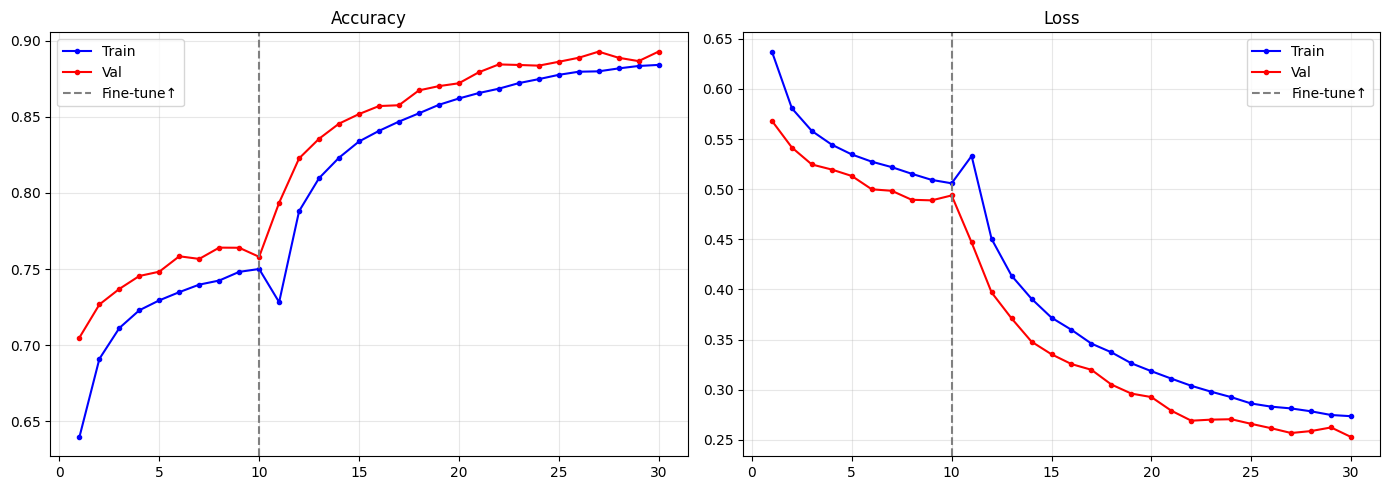

I0000 00:00:1776140945.116250    1218 service.cc:152] XLA service 0x7c484c58fba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776140945.121015    1218 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776140945.121031    1218 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-04-14 04:29:11.904695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 04:29:12.039613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 04:29:12.794023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

33580/33580 ━━━━━━━━━━━━━━━━━━━━ 204s 6ms/step
              precision    recall  f1-score   support

        FAKE       0.83      0.92      0.88     16790
        REAL       0.91      0.82      0.86     16790

    accuracy                           0.87     33580
   macro avg       0.87      0.87      0.87     33580
weighted avg       0.87      0.87      0.87     33580

 Test Accuracy : 87.03%
 AUC-ROC       : 0.9501


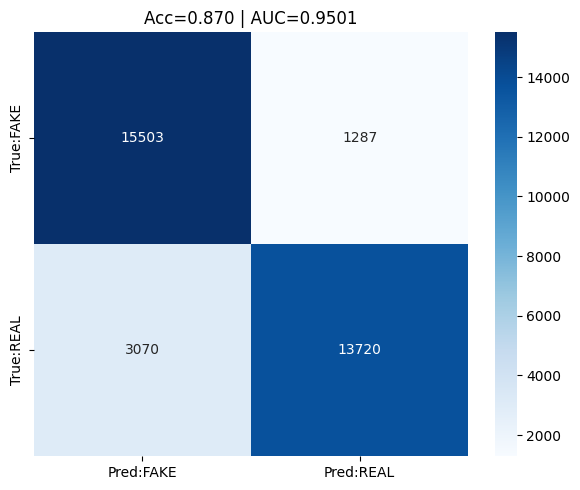


 Download from Output panel:
   /kaggle/working/best_model.h5


In [17]:

acc     = h1.history['accuracy']     + h2.history['accuracy']
val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss    = h1.history['loss']         + h2.history['loss']
val_l   = h1.history['val_loss']     + h2.history['val_loss']
ep      = range(1, len(acc)+1)
sp      = len(h1.history['loss'])

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
for ax,t,v,name in [(ax1,acc,val_acc,'Accuracy'),(ax2,loss,val_l,'Loss')]:
    ax.plot(ep,t,'b-o',ms=3,label='Train'); ax.plot(ep,v,'r-o',ms=3,label='Val')
    ax.axvline(sp,c='gray',ls='--',label='Fine-tune↑')
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png',dpi=150)
plt.show()


best_model = load_model(BEST_MODEL)
test_gen.reset()
preds  = best_model.predict(test_gen, verbose=1)
scores = preds.flatten()
plbls  = (scores > 0.5).astype(int)
tlbls  = np.array([1 if f.startswith('real') else 0 for f in test_gen.filenames])

print(classification_report(tlbls, plbls, target_names=['FAKE','REAL']))
auc = roc_auc_score(tlbls, scores)
acc_t = (plbls==tlbls).mean()
print(f" Test Accuracy : {acc_t*100:.2f}%")
print(f" AUC-ROC       : {auc:.4f}")


cm = confusion_matrix(tlbls, plbls)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Pred:FAKE','Pred:REAL'],
            yticklabels=['True:FAKE','True:REAL'])
plt.title(f'Acc={acc_t:.3f} | AUC={auc:.4f}')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png',dpi=150)
plt.show()

print("\n Download from Output panel:")
print("   /kaggle/working/best_model.h5")
